# Ekstraksi Optical Flow SMIC (untuk Vision Transformer)

## Peta proyek (baca dulu sebelum sidang)

Workspace aktif ada di `python test/`. Setiap arsitektur **diisolasi** di foldernya sendiri agar checkpoint `.pth` dan notebook tidak tercampur.

```text
python test/
├── discovery/          # EDA saja — tidak ada training
│   ├── smic_data_discovery.ipynb
│   └── mmew_data_discovery.ipynb
├── stgcn/              # model graf Face Mesh (468 node)
│   ├── stgcn_mmew_extraction.ipynb
│   ├── stgcn_mmew_pretraining.ipynb
│   ├── stgcn_smic_extraction.ipynb
│   ├── stgcn_smic_training.ipynb   # LOSO + transfer MMEW
│   ├── stgcn_mmew_pretrained.pth
│   ├── stgcn_best_model.pth
│   └── stgcn_mmew_landmarks/       # 300 file .npy MMEW
├── r3d18/              # 3D-CNN R3D-18 pada klip video
│   ├── r3d18_smic_pipeline.ipynb
│   └── r3d18_best_model.pth
├── vit/                # ViT pada gambar Optical Flow
│   ├── vit_optical_flow_pipeline.ipynb
│   └── vit_best_model.pth
├── dataset/            # data mentah + hasil ekstraksi bersama
│   ├── SMIC_all_cropped/           # frame BMP ter-crop & registrasi
│   ├── MMEW/                       # JPG mikro (sekuens) + makro (still)
│   ├── stgcn_smic_landmarks/       # .npy graf SMIC
│   └── vit_optical_flow_frames/    # JPG flow untuk ImageFolder
└── requirements.txt
```

**Alur skripsi yang benar:** discovery → ekstraksi fitur → (opsional pre-train) → LOSO SMIC. Ketiga model dievaluasi dengan protokol **LOSO** yang sama agar perbandingan adil (tanpa Subject Leakage dari split 80/20).

**Letak di peta:** `vit/` menulis `../dataset/vit_optical_flow_frames/` lalu fine-tune ViT. Input model adalah **satu gambar 224×224**, bukan video. Gerak temporal **dikompresi** ke warna Optical Flow.

**Mengapa Farneback, bukan RAFT?** Farneback tersedia di OpenCV tanpa bobot tambahan, cukup untuk gerak mikro wajah yang halus, dan reprodusibel untuk skripsi.

Notebook ini merangkum **gerakan temporal** setiap klip mikro-ekspresi SMIC menjadi **satu gambar spasial** menggunakan Dense Optical Flow (algoritma **Farneback**).

Mengapa diperlukan?

- Vision Transformer (ViT) menerima input gambar 2D, bukan video 5D.
- Optical Flow memetakan pergeseran piksel dari **onset** (awal gerakan) ke **apex** (puncak gerakan) menjadi peta warna RGB.
- Hasilnya bisa langsung dimuat oleh ViT lewat `ImageFolder`.

Pipeline:

1. Siapkan folder keluaran `dataset/vit_optical_flow_frames/{Negative,Positive,Surprise}`
2. Ambil indeks klip dari `micro_df` (atau bangun ulang dari folder HS/micro)
3. Hitung Farneback antara frame onset dan frame tengah (proksi apex)
4. Ubah vektor flow `(dx, dy)` menjadi gambar HSV → BGR, lalu resize **224×224**
5. Simpan `{nama_klip}_flow.jpg` untuk **seluruh** klip, lalu tampilkan sanity check
6. Muat hasil sebagai `ImageFolder` + evaluasi **LOSO** (Leave-One-Subject-Out)
7. Fine-tune Vision Transformer (`vit_base_patch16_224`) selama 15 epoch

> Jika notebook `smic_data_discovery.ipynb` sudah dijalankan pada kernel yang sama, DataFrame `micro_df` dipakai ulang.


In [1]:
# =============================================================================
# 1. IMPORT, KONFIGURASI PATH, DAN PARAMETER OPTICAL FLOW
# =============================================================================
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ==========================================
# KONFIGURASI EKSEKUSI (Lokal vs Server)
# ==========================================
RUN_ON_SERVER = False  # Ubah ke True jika dijalankan di server GPU berkapasitas tinggi

if RUN_ON_SERVER:
    CFG = {
        "epochs": 150,
        "batch_size": 32,
        "use_augmentation": True,
        "patience": 20,
        "num_workers": 4
    }
else:
    CFG = {
        "epochs": 2,
        "batch_size": 4,
        "use_augmentation": False,
        "patience": 2,
        "num_workers": 0
    }

print(f"Mode eksekusi : {'SERVER' if RUN_ON_SERVER else 'LOKAL'}")
print(f"CFG           : {CFG}")

# Root dataset SMIC (folder berisi HS / NIR / VIS)
DATASET_ROOT = Path('../dataset/SMIC_all_cropped').resolve()

# Folder keluaran Optical Flow — sibling dari SMIC_all_cropped agar siap ImageFolder
OUTPUT_ROOT = DATASET_ROOT.parent / 'vit_optical_flow_frames'

# Ukuran gambar yang akan dimuat ViT (resize hasil flow ke resolusi ini)
IMG_SIZE = 224

# Modalitas yang diekstrak. HS adalah standar pada pipeline 3D-CNN sebelumnya.
TARGET_MODALITY = 'HS'
EMOTION_CLASSES = ['Negative', 'Positive', 'Surprise']

# Parameter Farneback (standar OpenCV; winsize=15 cukup menangkap gerak mikro wajah)
# Piramida 3 level + winsize 15: jendela cukup lebar untuk gerak piksel kecil mikro-ekspresi,
# tanpa terlalu halus sampai menangkap noise sensor.
FARNEBACK_PARAMS = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0,
)

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder dataset tidak ditemukan: {DATASET_ROOT}\n'
        'Sesuaikan DATASET_ROOT dengan lokasi SMIC_all_cropped.'
    )

print(f'Dataset root : {DATASET_ROOT}')
print(f'Output root  : {OUTPUT_ROOT}')
print(f'IMG_SIZE     : {IMG_SIZE}')
print(f'Modalitas    : {TARGET_MODALITY}')


Dataset root : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/SMIC_all_cropped
Output root  : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames
IMG_SIZE     : 224
Modalitas    : HS


/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Setup Direktori Output

Struktur yang dibuat:

```text
dataset/
└── vit_optical_flow_frames/
    ├── Negative/
    ├── Positive/
    └── Surprise/
```

Setiap sub-folder kelas akan diisi file `{nama_klip}_flow.jpg`, sehingga tahap ViT nanti dapat memakai `torchvision.datasets.ImageFolder` tanpa pemetaan label manual.

In [2]:
# =============================================================================
# 2. BUAT FOLDER KELUARAN PER KELAS EMOSI
# =============================================================================
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

class_dirs = {}
for emotion in EMOTION_CLASSES:
    class_dir = OUTPUT_ROOT / emotion
    class_dir.mkdir(parents=True, exist_ok=True)
    class_dirs[emotion] = class_dir
    print(f'Siap: {class_dir}')

print(f'\nFolder Optical Flow: {OUTPUT_ROOT}')

Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames/Negative
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames/Positive
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames/Surprise

Folder Optical Flow: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames


## 3. Indeks Klip SMIC

Jika `micro_df` sudah ada di memori kernel (dari `smic_data_discovery.ipynb`), indeks itu dipakai ulang. Jika belum, notebook membangun indeks dari folder `HS/{subjek}/micro/{emosi}/{klip}`.

In [3]:
# =============================================================================
# 3. SIAPKAN DAFTAR KLIP (micro_df ATAU BANGUN ULANG DARI FOLDER)
# =============================================================================
def frame_sort_key(frame_path: Path):
    """Urutkan nama file berdasarkan angka terakhir, bukan alfabet murni.

    Contoh: reg_image9.bmp harus muncul sebelum reg_image10.bmp.
    """
    numbers = re.findall(r'\d+', frame_path.stem)
    return (0, int(numbers[-1])) if numbers else (1, frame_path.name)


def list_clip_frames(clip_dir: str | Path) -> list[Path]:
    """Ambil seluruh frame .bmp di dalam satu folder klip, tersortir numerik."""
    clip_dir = Path(clip_dir)
    frames = [
        path for path in clip_dir.iterdir()
        if path.is_file() and path.suffix.lower() == '.bmp'
    ]
    return sorted(frames, key=frame_sort_key)


def build_hs_micro_index(dataset_root: Path) -> pd.DataFrame:
    """Cari folder klip pada pola */HS/{subjek}/micro/{emosi}/{nama_klip}."""
    records = []
    hs_root = dataset_root / 'HS'
    if not hs_root.is_dir():
        raise FileNotFoundError(f'Folder HS tidak ditemukan: {hs_root}')

    for clip_dir in sorted(hs_root.glob('*/micro/*/*')):
        if not clip_dir.is_dir():
            continue

        frames = list_clip_frames(clip_dir)
        if not frames:
            continue

        emotion_label = clip_dir.parent.name.capitalize()
        if emotion_label not in EMOTION_CLASSES:
            continue

        records.append({
            'sequence_path': str(clip_dir.resolve()),
            'subject_id': clip_dir.parts[-4],
            'emotion_label': emotion_label,
            'sequence_id': clip_dir.name,
            'num_frames': len(frames),
            'modality': 'HS',
            'sample_type': 'Micro',
        })

    return pd.DataFrame(records)


# Pakai micro_df dari notebook discovery jika tersedia; jika tidak, bangun ulang.
if 'micro_df' in globals() and isinstance(micro_df, pd.DataFrame) and not micro_df.empty:
    clip_df = micro_df.copy()
    print('Menggunakan micro_df dari tahap eksplorasi sebelumnya.')
else:
    clip_df = build_hs_micro_index(DATASET_ROOT)
    print('micro_df tidak tersedia di kernel. Indeks klip dibangun dari folder HS/micro.')

# Filter ketat: hanya modalitas target + tiga kelas mikro-ekspresi
clip_df = clip_df[
    (clip_df['modality'] == TARGET_MODALITY)
    & (clip_df['sample_type'] == 'Micro')
    & (clip_df['emotion_label'].isin(EMOTION_CLASSES))
].copy()

if 'sequence_path' not in clip_df.columns:
    raise KeyError('Kolom sequence_path tidak ditemukan pada DataFrame indeks.')

# Pastikan ada kolom nama klip untuk penamaan file keluaran
if 'sequence_id' not in clip_df.columns:
    clip_df['sequence_id'] = clip_df['sequence_path'].map(lambda p: Path(p).name)

clip_df = clip_df.reset_index(drop=True)

print(f'\nTotal klip {TARGET_MODALITY}/micro: {len(clip_df)}')
print('Distribusi kelas:')
print(clip_df['emotion_label'].value_counts().reindex(EMOTION_CLASSES))
clip_df.head()

micro_df tidak tersedia di kernel. Indeks klip dibangun dari folder HS/micro.

Total klip HS/micro: 164
Distribusi kelas:
emotion_label
Negative    70
Positive    51
Surprise    43
Name: count, dtype: int64


,sequence_path,subject_id,emotion_label,sequence_id,num_frames,modality,sample_type
0,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_01,36,HS,Micro
1,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_02,32,HS,Micro
2,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_03,27,HS,Micro
3,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Positive,s1_po_01,23,HS,Micro
4,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Positive,s1_po_02,30,HS,Micro


## 4. Fungsi Perhitungan Optical Flow (Farneback)

Untuk setiap klip:

- **Frame A (onset)** = frame pertama (indeks `0`)
- **Frame B (apex)** = frame tengah (`len(frames) // 2`) sebagai proksi puncak gerakan, karena anotasi apex SMIC tidak selalu tersedia di folder BMP

Vektor flow `(dx, dy)` diubah ke ruang HSV:

- **Hue** = arah gerakan
- **Value** = magnitudo gerakan
- **Saturation** = penuh (255)

Kemudian dikonversi ke BGR/RGB agar tampak seperti peta panas otot wajah.
**Onset vs apex:** mikro-ekspresi = gerak singkat onset→apex→offset. Mengambil frame 0 dan frame tengah adalah proksi apex ketika anotasi frame apex tidak ada di folder BMP.


In [4]:
# =============================================================================
# 4. FUNGSI OPTICAL FLOW: ONSET → APEX (FARNEBACK)
# =============================================================================
def flow_to_bgr(flow: np.ndarray) -> np.ndarray:
    """Ubah field flow (H, W, 2) menjadi gambar warna BGR via HSV."""
    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    # Hue menyandi ARAH vektor (dx,dy). Value menyandi BESARAN. Saturation penuh agar warna jenuh.
    hsv[..., 0] = angle * 180 / np.pi / 2          # Hue: arah (0–180 di OpenCV)
    hsv[..., 1] = 255                               # Saturation: penuh
    hsv[..., 2] = cv2.normalize(                    # Value: kekuatan gerakan
        magnitude, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def compute_optical_flow(clip_folder_path: str | Path, img_size: int = IMG_SIZE) -> dict:
    """Hitung Dense Optical Flow Farneback dari satu folder klip SMIC.

    Parameters
    ----------
    clip_folder_path : str | Path
        Folder klip berisi urutan frame .bmp.
    img_size : int
        Resolusi keluaran (default 224) untuk input ViT.

    Returns
    -------
    dict
        onset_bgr, apex_bgr, flow_bgr (semua sudah di-resize), serta metadata frame.
    """
    clip_dir = Path(clip_folder_path)
    frame_paths = list_clip_frames(clip_dir)
    if len(frame_paths) < 2:
        raise ValueError(
            f'Klip membutuhkan minimal 2 frame untuk Optical Flow: {clip_dir}'
        )

    # Frame A = onset (awal); Frame B = apex proksi (tengah sequence)
    onset_idx = 0
    apex_idx = len(frame_paths) // 2
    onset_path = frame_paths[onset_idx]
    apex_path = frame_paths[apex_idx]

    onset_bgr = cv2.imread(str(onset_path), cv2.IMREAD_COLOR)
    apex_bgr = cv2.imread(str(apex_path), cv2.IMREAD_COLOR)
    if onset_bgr is None or apex_bgr is None:
        raise IOError(f'Gagal membaca frame onset/apex di {clip_dir}')

    # Farneback bekerja pada grayscale; hitung di resolusi asli agar gerak mikro tidak hilang
    onset_gray = cv2.cvtColor(onset_bgr, cv2.COLOR_BGR2GRAY)
    apex_gray = cv2.cvtColor(apex_bgr, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        onset_gray,
        apex_gray,
        None,
        **FARNEBACK_PARAMS,
    )

    flow_bgr = flow_to_bgr(flow)
    target_size = (img_size, img_size)

    return {
        'onset_bgr': cv2.resize(onset_bgr, target_size, interpolation=cv2.INTER_AREA),
        'apex_bgr': cv2.resize(apex_bgr, target_size, interpolation=cv2.INTER_AREA),
        'flow_bgr': cv2.resize(flow_bgr, target_size, interpolation=cv2.INTER_AREA),
        'onset_path': onset_path,
        'apex_path': apex_path,
        'onset_idx': onset_idx,
        'apex_idx': apex_idx,
        'num_frames': len(frame_paths),
    }


## 5. Eksekusi Batch

Setiap klip valid di `clip_df` diekstrak, lalu disimpan ke:

```text
vit_optical_flow_frames/{kelas}/{nama_klip}_flow.jpg
```

In [5]:
# =============================================================================
# 5. LOOP EKSTRAKSI SELURUH KLIP SMIC
# =============================================================================
extraction_records = []
n_success = 0
n_failed = 0

for _, row in tqdm(clip_df.iterrows(), total=len(clip_df), desc='Optical Flow SMIC'):
    clip_path = Path(row['sequence_path'])
    emotion = row['emotion_label']
    clip_name = row['sequence_id']
    save_path = class_dirs[emotion] / f'{clip_name}_flow.jpg'

    try:
        result = compute_optical_flow(clip_path, img_size=IMG_SIZE)
        # Simpan JPEG berkualitas tinggi agar artefak kompresi tidak merusak peta gerak
        ok = cv2.imwrite(str(save_path), result['flow_bgr'], [cv2.IMWRITE_JPEG_QUALITY, 95])
        if not ok:
            raise IOError(f'Gagal menulis file: {save_path}')

        extraction_records.append({
            'sequence_id': clip_name,
            'emotion_label': emotion,
            'sequence_path': str(clip_path),
            'flow_path': str(save_path),
            'onset_idx': result['onset_idx'],
            'apex_idx': result['apex_idx'],
            'num_frames': result['num_frames'],
            'status': 'ok',
        })
        n_success += 1
    except Exception as exc:
        extraction_records.append({
            'sequence_id': clip_name,
            'emotion_label': emotion,
            'sequence_path': str(clip_path),
            'flow_path': str(save_path),
            'onset_idx': None,
            'apex_idx': None,
            'num_frames': None,
            'status': f'error: {exc}',
        })
        n_failed += 1

flow_index_df = pd.DataFrame(extraction_records)
index_csv = OUTPUT_ROOT / 'optical_flow_index.csv'
flow_index_df.to_csv(index_csv, index=False)

print(f'\nBerhasil : {n_success}')
print(f'Gagal    : {n_failed}')
print(f'Indeks   : {index_csv}')
print('\nJumlah file per kelas:')
print(flow_index_df.loc[flow_index_df['status'] == 'ok', 'emotion_label'].value_counts().reindex(EMOTION_CLASSES))
flow_index_df.head()

Optical Flow SMIC:   0%|          | 0/164 [00:00<?, ?it/s]

Optical Flow SMIC:  13%|█▎        | 22/164 [00:00<00:00, 215.99it/s]

Optical Flow SMIC:  28%|██▊       | 46/164 [00:00<00:00, 229.37it/s]

Optical Flow SMIC:  43%|████▎     | 71/164 [00:00<00:00, 235.01it/s]

Optical Flow SMIC:  60%|█████▉    | 98/164 [00:00<00:00, 245.15it/s]

Optical Flow SMIC:  76%|███████▌  | 125/164 [00:00<00:00, 253.24it/s]

Optical Flow SMIC:  92%|█████████▏| 151/164 [00:00<00:00, 250.98it/s]

Optical Flow SMIC: 100%|██████████| 164/164 [00:00<00:00, 244.36it/s]


Berhasil : 164
Gagal    : 0
Indeks   : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames/optical_flow_index.csv

Jumlah file per kelas:
emotion_label
Negative    70
Positive    51
Surprise    43
Name: count, dtype: int64


,sequence_id,emotion_label,sequence_path,flow_path,onset_idx,apex_idx,num_frames,status
0,s1_ne_01,Negative,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,0,18,36,ok
1,s1_ne_02,Negative,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,0,16,32,ok
2,s1_ne_03,Negative,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,0,13,27,ok
3,s1_po_01,Positive,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,0,11,23,ok
4,s1_po_02,Positive,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,0,15,30,ok


## 6. Visualisasi Sanity Check

Tiga panel untuk satu klip contoh:

- **Kiri** — Frame Awal (onset)
- **Tengah** — Frame Puncak (apex proksi)
- **Kanan** — Optical Flow RGB hasil ekstraksi

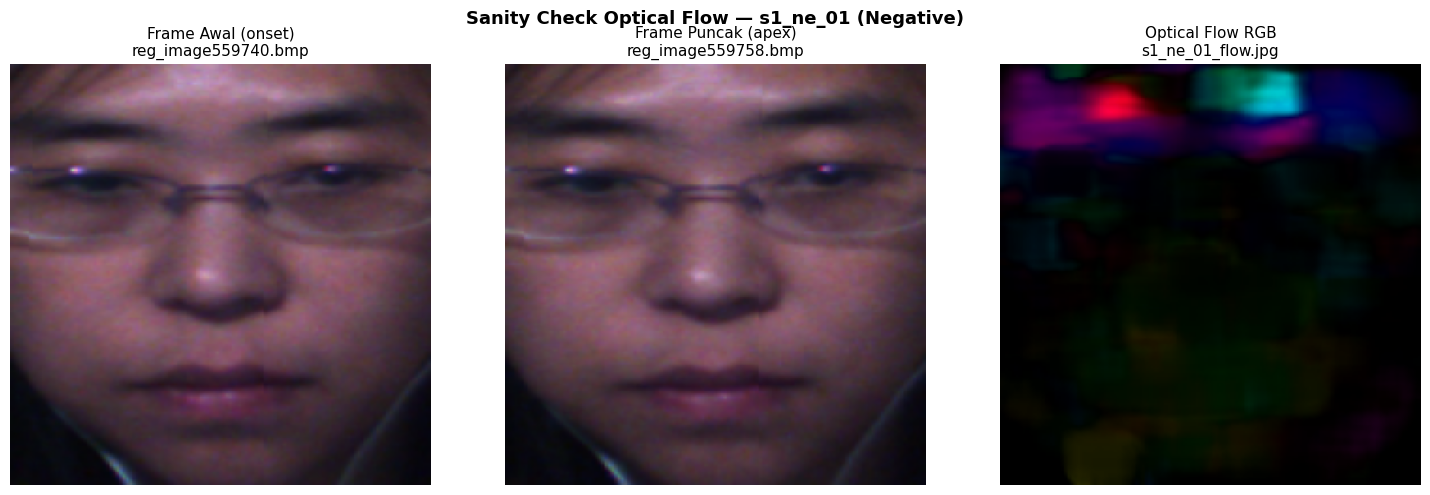

Klip contoh     : s1_ne_01
Kelas           : Negative
Onset idx       : 0
Apex idx        : 18 / 35
Ukuran flow RGB : (224, 224, 3)  (H, W, C)
File tersimpan  : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/vit_optical_flow_frames/Negative/s1_ne_01_flow.jpg


In [6]:
# =============================================================================
# 6. SANITY CHECK: ONSET | APEX | OPTICAL FLOW
# =============================================================================
ok_rows = flow_index_df[flow_index_df['status'] == 'ok']
if ok_rows.empty:
    raise RuntimeError('Tidak ada klip yang berhasil diekstrak untuk visualisasi.')

# Ambil satu contoh (klip pertama yang sukses)
sample = ok_rows.iloc[0]
sample_result = compute_optical_flow(sample['sequence_path'], img_size=IMG_SIZE)

# OpenCV = BGR; matplotlib menampilkan RGB
onset_rgb = cv2.cvtColor(sample_result['onset_bgr'], cv2.COLOR_BGR2RGB)
apex_rgb = cv2.cvtColor(sample_result['apex_bgr'], cv2.COLOR_BGR2RGB)
flow_rgb = cv2.cvtColor(sample_result['flow_bgr'], cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panel_data = [
    (onset_rgb, f"Frame Awal (onset)\n{sample_result['onset_path'].name}"),
    (apex_rgb, f"Frame Puncak (apex)\n{sample_result['apex_path'].name}"),
    (flow_rgb, f"Optical Flow RGB\n{Path(sample['flow_path']).name}"),
]

for ax, (image, title) in zip(axes, panel_data):
    ax.imshow(image)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

fig.suptitle(
    f"Sanity Check Optical Flow — {sample['sequence_id']} ({sample['emotion_label']})",
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

print(f"Klip contoh     : {sample['sequence_id']}")
print(f"Kelas           : {sample['emotion_label']}")
print(f"Onset idx       : {sample_result['onset_idx']}")
print(f"Apex idx        : {sample_result['apex_idx']} / {sample_result['num_frames'] - 1}")
print(f"Ukuran flow RGB : {flow_rgb.shape}  (H, W, C)")
print(f"File tersimpan  : {sample['flow_path']}")

## 7. ImageFolder & Persiapan LOSO untuk ViT

Hasil Optical Flow dimuat dengan `torchvision.datasets.ImageFolder`.

Split acak 80/20 **diganti LOSO** agar perbandingan dengan ST-GCN dan 3D-CNN adil secara akademis — **Subject Leakage** dicegah dengan menahan seluruh klip satu subjek sebagai validasi per fold.
**ImageFolder** mengikat label ke **nama folder** (`Negative/`, …). Itu sebabnya ekstraksi harus menyimpan JPG persis di hierarki kelas. LOSO tidak memakai `random_split`: subject ID diparse dari nama file `s1_ne_01_flow.jpg`.


In [7]:
# =============================================================================
# 7. IMAGEFOLDER + EKSTRAKSI SUBJECT ID + PEMBAGIAN LOSO
# =============================================================================
import re
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import LeaveOneGroupOut

# Statistik ImageNet — wajib untuk ViT pre-trained
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Batch 16 aman: satu flow 224×224 vs klip R3D 16×112×112. ViT-Base tetap berat, 16 adalah kompromi.
BATCH_SIZE = CFG["batch_size"]
RANDOM_SEED = 42
NUM_WORKERS = CFG["num_workers"]
USE_AUGMENTATION = CFG["use_augmentation"]

# Pastikan ekstraksi batch sudah menghasilkan file JPG di sub-folder kelas
n_flow_images = sum(
    1
    for emotion in EMOTION_CLASSES
    for path in class_dirs[emotion].glob('*_flow.jpg')
)
if n_flow_images == 0:
    raise FileNotFoundError(
        f'Belum ada gambar Optical Flow di {OUTPUT_ROOT}. '
        'Jalankan cell ekstraksi batch (bagian 5) terlebih dahulu.'
    )

vit_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

flow_dataset = datasets.ImageFolder(
    root=str(OUTPUT_ROOT),
    transform=vit_transforms,
    is_valid_file=lambda p: Path(p).name.endswith('_flow.jpg'),
)
LABEL_TO_INDEX = flow_dataset.class_to_idx
INDEX_TO_LABEL = {idx: name for name, idx in LABEL_TO_INDEX.items()}


def parse_subject_id(file_name: str) -> str:
    """Ambil ID subjek dari nama file flow, misalnya 's1_ne_01_flow.jpg' -> 's1'."""
    match = re.match(r'(s\d+)', Path(file_name).stem, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f'ID subjek tidak dapat diekstrak dari: {file_name}')
    return match.group(1).lower()


# groups[i] = ID subjek pemilik gambar ke-i
groups = [parse_subject_id(Path(path).name) for path, _ in flow_dataset.samples]
labels_all = [label for _, label in flow_dataset.samples]

# LOSO mencegah Subject Leakage pada evaluasi ViT
logo = LeaveOneGroupOut()
fold_splits = list(
    logo.split(X=np.arange(len(flow_dataset)), y=labels_all, groups=groups)
)
n_folds = len(fold_splits)

print(f'Total gambar Optical Flow : {len(flow_dataset)}')
print(f'Kelas ImageFolder         : {LABEL_TO_INDEX}')
print(f'Jumlah subjek             : {len(set(groups))} -> {n_folds} fold LOSO')
print(f'Batch size                : {BATCH_SIZE}')
print('Distribusi kelas:')
for class_name, class_idx in LABEL_TO_INDEX.items():
    n_class = sum(1 for _, label in flow_dataset.samples if label == class_idx)
    print(f'  {class_name:10s}: {n_class}')

# --- Sanity check dimensi 1 batch dari fold pertama ---
check_train_idx, _ = fold_splits[0]
check_loader = DataLoader(
    Subset(flow_dataset, check_train_idx.tolist()),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
images, labels = next(iter(check_loader))
print('\nSanity check 1 batch (fold 1, data train):')
print(f'  images shape : {tuple(images.shape)}  (N, C, H, W)')
print(f'  labels shape : {tuple(labels.shape)}')
print(f'  label names  : {[INDEX_TO_LABEL[int(x)] for x in labels[:8]]} ...')


Total gambar Optical Flow : 164
Kelas ImageFolder         : {'Negative': 0, 'Positive': 1, 'Surprise': 2}
Jumlah subjek             : 16 -> 16 fold LOSO
Batch size                : 16
Distribusi kelas:
  Negative  : 70
  Positive  : 51
  Surprise  : 43

Sanity check 1 batch (fold 1, data train):
  images shape : (16, 3, 224, 224)  (N, C, H, W)
  labels shape : (16,)
  label names  : ['Positive', 'Negative', 'Negative', 'Negative', 'Positive', 'Negative', 'Positive', 'Positive'] ...


## 8. Vision Transformer (`vit_base_patch16_224`)

ViT-Base memotong gambar 224×224 menjadi patch 16×16, lalu mengklasifikasikan peta Optical Flow ke 3 kelas SMIC.

- Bobot pre-trained ImageNet dari `timm` dipakai sebagai inisialisasi
- Head klasifikasi diganti menjadi **3 kelas** (Negative, Positive, Surprise)
- Learning rate kecil (`1e-4`) karena ini fine-tuning, bukan training from scratch

Jika `timm` belum terpasang, jalankan di terminal:

```bash
pip install timm
```

atau di cell Jupyter: `%pip install timm`

In [8]:
# =============================================================================
# 8. DEVICE, FACTORY MODEL ViT, LOSS, OPTIMIZER, DAN SCHEDULER
# =============================================================================
# Jika timm belum terpasang, jalankan di terminal:  pip install timm
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, recall_score

try:
    import timm
except ImportError as exc:
    raise ImportError(
        'Library timm belum terpasang. Install dulu dengan:\n'
        '  pip install timm\n'
        'atau di Jupyter:\n'
        '  %pip install timm'
    ) from exc

required_vars = ['flow_dataset', 'fold_splits', 'groups', 'LABEL_TO_INDEX']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise NameError(
        'Variabel belum tersedia: ' + ', '.join(missing) + '. '
        'Jalankan cell ImageFolder/LOSO terlebih dahulu.'
    )

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device yang digunakan: {device}')

num_classes = len(LABEL_TO_INDEX)
print(f'Jumlah kelas         : {num_classes}')
print(f'Urutan kelas         : {LABEL_TO_INDEX}')
print(f'Jumlah fold LOSO     : {len(fold_splits)}')

criterion_vit = nn.CrossEntropyLoss()


def create_fresh_model_vit(seed: int = RANDOM_SEED):
    """Buat model ViT, optimizer, dan scheduler yang benar-benar baru.

    WAJIB dipanggil di setiap fold LOSO agar tidak terjadi weight leakage
    antar subjek (Subject Leakage).
    """
    torch.manual_seed(seed)

    # vit_base_patch16_224: gambar 224×224 dipecah patch 16×16 → 196 token + 1 CLS.
    # pretrained=True memuat ImageNet; tanpa itu ViT-Base (86 juta param) tidak konvergen di 164 sampel.
    model = timm.create_model('vit_base_patch16_224', pretrained=True)
    # Ganti kepala ImageNet (1000 kelas) dengan 3 kelas SMIC. Backbone patch/transformer tetap.
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)
    model = model.to(device)

    # Fine-tune ViT ImageNet: LR 1e-4 (bukan 1e-3) agar patch embedding dan attention tidak rusak.
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=CFG["patience"],
    )
    return model, optimizer, scheduler


probe_model, _, _ = create_fresh_model_vit()
probe_model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    dummy_out = probe_model(dummy)
print(f'Sanity check input  : {tuple(dummy.shape)}  (B, C, H, W)')
print(f'Sanity check output : {tuple(dummy_out.shape)}  (harus (1, {num_classes}))')
print('\nFactory ViT-Base siap untuk LOSO.')
print('create_fresh_model_vit() -> model, optimizer, scheduler baru per fold')
del probe_model


Device yang digunakan: mps
Jumlah kelas         : 3
Urutan kelas         : {'Negative': 0, 'Positive': 1, 'Surprise': 2}
Jumlah fold LOSO     : 16


Sanity check input  : (1, 3, 224, 224)  (B, C, H, W)
Sanity check output : (1, 3)  (harus (1, 3))

Factory ViT-Base siap untuk LOSO.
create_fresh_model_vit() -> model, optimizer, scheduler baru per fold


## 9. Fungsi Training Satu Fold ViT

Metrik: Accuracy, Macro F1, dan UAR. Prediksi diakumulasi dari **epoch terakhir** setiap fold LOSO agar evaluasi global tetap jujur (tidak memilih epoch terbaik berdasarkan data validasi).
**Kerangka identik dengan R3D-18:** `run_epoch` → `train_one_fold` → akumulasi prediksi epoch terakhir. Perbedaannya hanya input: gambar flow `(N,3,224,224)` vs video `(N,3,16,112,112)`.


In [9]:
# =============================================================================
# 9. FUNGSI TRAINING & VALIDASI ViT (SAMA DENGAN KERANGKA 3D-CNN)
# =============================================================================
def compute_classification_metrics(y_true, y_pred, num_classes: int):
    """Hitung accuracy, macro-F1, dan UAR (macro-recall) dari prediksi integer."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) == 0:
        return {'accuracy': 0.0, 'macro_f1': 0.0, 'uar': 0.0}

    accuracy = float((y_true == y_pred).mean())
    labels = list(range(num_classes))
    macro_f1 = float(
        # Macro: rata-rata F1 ketiga kelas sama rata. zero_division=0 mencegah error jika
        # fold validasi tidak punya salah satu kelas (beberapa subjek SMIC hanya 1-2 emosi).
        f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    )
    uar = float(
        recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    )
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'uar': uar}


def run_epoch_vit(model, loader, criterion, optimizer, is_training: bool):
    """Jalankan satu epoch train/eval untuk ViT."""
    model.train() if is_training else model.eval()

    running_loss = 0.0
    total_samples = 0
    all_true = []
    all_pred = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            # ViT mengeluarkan logit (N, 3). CrossEntropyLoss sudah memuat log-softmax;
            # jangan softmax manual sebelum loss. argmax = kelas dengan skor tertinggi.
            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
        all_true.extend(labels.detach().cpu().tolist())
        all_pred.extend(predictions.detach().cpu().tolist())

    return {
        'loss': running_loss / max(total_samples, 1),
        'y_true': all_true,
        'y_pred': all_pred,
    }


def train_one_fold_vit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs: int = 15,
    progress_desc: str = '',
):
    """Latih satu fold LOSO ViT, kembalikan prediksi epoch terakhir."""
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_macro_f1': [],
        'val_uar': [],
        'learning_rate': [],
    }
    final_val_result = None

    for _ in tqdm(range(num_epochs), desc=progress_desc, leave=False):
        train_result = run_epoch_vit(
            model, train_loader, criterion, optimizer, is_training=True
        )
        val_result = run_epoch_vit(
            model, val_loader, criterion, optimizer, is_training=False
        )

        train_metrics = compute_classification_metrics(
            train_result['y_true'], train_result['y_pred'], num_classes
        )
        val_metrics = compute_classification_metrics(
            val_result['y_true'], val_result['y_pred'], num_classes
        )

        scheduler.step(val_metrics['macro_f1'])

        history['train_loss'].append(train_result['loss'])
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_loss'].append(val_result['loss'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        history['val_uar'].append(val_metrics['uar'])
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        final_val_result = val_result

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return {
        'history': history,
        'y_true': final_val_result['y_true'],
        'y_pred': final_val_result['y_pred'],
        'val_loss': history['val_loss'][-1],
        'val_accuracy': history['val_accuracy'][-1],
    }


print('Fungsi training siap:')
print('  run_epoch_vit()      -> satu epoch train/eval ViT')
print('  train_one_fold_vit() -> latih satu fold LOSO')


Fungsi training siap:
  run_epoch_vit()      -> satu epoch train/eval ViT
  train_one_fold_vit() -> latih satu fold LOSO


## 10. Jalankan LOSO Cross-Validation ViT

16 fold (16 subjek), masing-masing **15 epoch**. Model ViT di-reset total per fold. Metrik global dihitung dari akumulasi 164 prediksi.
**Factory per fold** `create_fresh_model_vit()` wajib: tanpa reset, bobot subjek fold sebelumnya merembes. Checkpoint `vit_best_model.pth` hanya untuk inferensi demo, **bukan** sumber metrik skripsi (metrik skripsi = akumulasi 164 prediksi LOSO).


In [10]:
# =============================================================================
# 10. LOOP LOSO + EVALUASI GLOBAL ViT
# =============================================================================
NUM_EPOCHS_VIT = CFG["epochs"]
CHECKPOINT_VIT = 'vit_best_model.pth'

loso_y_true = []
loso_y_pred = []
fold_results = []

best_fold_accuracy = float('-inf')
best_fold_state = None
best_fold_subject = None

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    val_subject = groups[val_idx[0]]
    print(f'\nFold {fold_idx + 1}/{n_folds} - Validasi Subjek: {val_subject}')
    print('-' * 80)

    train_loader = DataLoader(
        Subset(flow_dataset, train_idx.tolist()),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        Subset(flow_dataset, val_idx.tolist()),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    # RESET total model/optimizer/scheduler — cegah weight leakage antar fold
    # Model, optimizer, scheduler baru. Fine-tune ImageNet diulang dari awal setiap fold.
    model_fold, optimizer_fold, scheduler_fold = create_fresh_model_vit()

    fold_output = train_one_fold_vit(
        model=model_fold,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_vit,
        optimizer=optimizer_fold,
        scheduler=scheduler_fold,
        num_epochs=NUM_EPOCHS_VIT,
        progress_desc=f'Fold {fold_idx + 1} ({val_subject})',
    )

    loso_y_true.extend(fold_output['y_true'])
    loso_y_pred.extend(fold_output['y_pred'])

    fold_accuracy = fold_output['val_accuracy']
    fold_results.append({
        'fold': fold_idx + 1,
        'subjek': val_subject,
        'n_train': len(train_idx),
        'n_val': len(val_idx),
        'val_accuracy': fold_accuracy,
        'benar': int(np.sum(np.array(fold_output['y_true']) == np.array(fold_output['y_pred']))),
    })

    if fold_accuracy > best_fold_accuracy:
        best_fold_accuracy = fold_accuracy
        best_fold_subject = val_subject
        best_fold_state = {k: v.detach().cpu().clone() for k, v in model_fold.state_dict().items()}

    print(
        f'Train Loss akhir: {fold_output["history"]["train_loss"][-1]:.4f} | '
        f'Train Acc akhir: {fold_output["history"]["train_accuracy"][-1] * 100:.2f}%'
    )
    print(
        f'Val Loss  akhir: {fold_output["val_loss"]:.4f} | '
        f'Val Accuracy   : {fold_accuracy * 100:.2f}% '
        f'({fold_results[-1]["benar"]}/{len(val_idx)} benar)'
    )

torch.save(best_fold_state, CHECKPOINT_VIT)

global_metrics = compute_classification_metrics(loso_y_true, loso_y_pred, num_classes)

print('\n' + '=' * 80)
print('HASIL AKHIR LOSO — ViT (Optical Flow)')
print('=' * 80)
print(f'Jumlah fold          : {n_folds} subjek')
print(f'Total sampel diuji   : {len(loso_y_true)}')
print(f'Epoch per fold       : {NUM_EPOCHS_VIT}')
print('-' * 80)
print(f"Keseluruhan Accuracy : {global_metrics['accuracy'] * 100:.2f}%")
print(f"Keseluruhan Macro F1 : {global_metrics['macro_f1'] * 100:.2f}%")
print(f"Keseluruhan UAR      : {global_metrics['uar'] * 100:.2f}%")
print('=' * 80)
print(f'Checkpoint tersimpan : {CHECKPOINT_VIT} (fold terbaik: {best_fold_subject})')



Fold 1/16 - Validasi Subjek: s1
--------------------------------------------------------------------------------


Fold 1 (s1):   0%|          | 0/15 [00:00<?, ?it/s]

Fold 1 (s1):   7%|▋         | 1/15 [00:07<01:49,  7.79s/it]

Fold 1 (s1):  13%|█▎        | 2/15 [00:14<01:31,  7.04s/it]

Fold 1 (s1):  20%|██        | 3/15 [00:20<01:21,  6.80s/it]

...

Fold 16 (s9):  87%|████████▋ | 13/15 [01:31<00:14,  7.03s/it]

Fold 16 (s9):  93%|█████████▎| 14/15 [01:38<00:07,  7.03s/it]

Fold 16 (s9): 100%|██████████| 15/15 [01:45<00:00,  7.02s/it]

Train Loss akhir: 0.5416 | Train Acc akhir: 77.50%
Val Loss  akhir: 1.7250 | Val Accuracy   : 0.00% (0/4 benar)



HASIL AKHIR LOSO — ViT (Optical Flow)
Jumlah fold          : 16 subjek
Total sampel diuji   : 164
Epoch per fold       : 15
--------------------------------------------------------------------------------
Keseluruhan Accuracy : 43.90%
Keseluruhan Macro F1 : 41.68%
Keseluruhan UAR      : 41.92%
Checkpoint tersimpan : vit_best_model.pth (fold terbaik: s2)
